In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
def process_star_data(file_path, num_points=100):
    """
    نفس preprocessing الـ forward model بالظبط.
    X  = الأبعاد السبعة  ← هتبقى OUTPUT في الـ inverse
    yt = thrust profile  ← هتبقى INPUT
    yp = pressure profile← هتبقى INPUT  
    ys = scalars (4)     ← هتبقى INPUT
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    print('Loading data...')
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()

    # Fix floating point noise
    df['Throat_Diameter'] = df['Throat_Diameter'].round(2)
    df['Exit_Diameter']   = df['Exit_Diameter'].round(2)

    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    ids = df['Model_ID'].dropna().unique()
    print(f'Total simulations: {len(ids)}')

    INPUT_COLS = [
        'Length', 'Diameter', 'Number_Of_Points',
        'Point_Length', 'Point_Base_Width',
        'Throat_Diameter', 'Exit_Diameter'
    ]

    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in ids:
        try:
            case = df[df['Model_ID'] == uid].sort_values('Time (s)')
            inputs = case[INPUT_COLS].iloc[0].values
            t      = case['Time (s)'].values

            if len(t) < 2 or t[-1] <= 0 or np.any(inputs <= 0):
                continue

            thrust   = case['Thrust (N)'].fillna(0).values
            pressure = case['Pressure (MPa)'].fillna(0).values

            if len(thrust) > 7:
                thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(inputs)
            y_thrust.append(interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            y_scalars.append([
                case['ISP (s)'].iloc[0],
                case['Total Impulse (Ns)'].iloc[0],
                t[-1],
                np.max(thrust)
            ])
        except Exception:
            continue

    X          = np.array(X,          dtype=float)
    y_thrust   = np.array(y_thrust,   dtype=float)
    y_pressure = np.array(y_pressure, dtype=float)
    y_scalars  = np.array(y_scalars,  dtype=float)

    print(f'Done: {len(X)} cases')
    print(f'  Dimensions  (X):  {X.shape}          → 7 outputs')
    print(f'  Thrust      (yt): {y_thrust.shape}   → 100 inputs')
    print(f'  Pressure    (yp): {y_pressure.shape} → 100 inputs')
    print(f'  Scalars     (ys): {y_scalars.shape}  → 4 inputs')
    return X, y_thrust, y_pressure, y_scalars


# ── تغيير المسار حسب بيئتك ──────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mahmoudabdelrazekk/data-star/Star_Dataset.csv'
# DATA_PATH = 'Star_Dataset.csv'
# ────────────────────────────────────────────────────────

X, yt, yp, ys = process_star_data(DATA_PATH)

# ── Train / Test Split ────────────────────────────────────────────────
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = \
    train_test_split(X, yt, yp, ys, test_size=0.15, random_state=42)

# ── Scalers ───────────────────────────────────────────────────────────
# MinMaxScaler للـ dimensions (outputs) — نفس Bates inverse
# sigmoid activation في آخر الموديل بتطلع 0→1، MinMaxScaler يتناسب معاها تماماً
s_X  = MinMaxScaler()
X_tr_s = s_X.fit_transform(X_train)
X_te_s = s_X.transform(X_test)

# StandardScaler للـ inputs (profiles + scalars)
s_yt = StandardScaler(); yt_tr_s = s_yt.fit_transform(yt_train); yt_te_s = s_yt.transform(yt_test)
s_yp = StandardScaler(); yp_tr_s = s_yp.fit_transform(yp_train); yp_te_s = s_yp.transform(yp_test)
s_ys = StandardScaler(); ys_tr_s = s_ys.fit_transform(ys_train); ys_te_s = s_ys.transform(ys_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Scalers fitted ✓')

# حفظ الـ scalers فوراً عشان ما تتحتاجش تعيد التدريب
joblib.dump(s_X,  'star_inv_scaler_dimensions.pkl')
joblib.dump(s_yt, 'star_inv_scaler_thrust.pkl')
joblib.dump(s_yp, 'star_inv_scaler_pressure.pkl')
joblib.dump(s_ys, 'star_inv_scaler_scalars.pkl')
print('Scalers saved ✓')

Loading data...
Total simulations: 4202
Done: 4202 cases
  Dimensions  (X):  (4202, 7)          → 7 outputs
  Thrust      (yt): (4202, 100)   → 100 inputs
  Pressure    (yp): (4202, 100) → 100 inputs
  Scalars     (ys): (4202, 4)  → 4 inputs
Train: 3571 | Test: 631
Scalers fitted ✓
Scalers saved ✓


In [7]:
def build_star_inverse_model():
    """
    Multi-input → Single output:
      Thrust profile  (100,) ┐
      Pressure profile(100,) ├─→ Shared backbone → Dimensions (7,)
      Scalars          (4,)  ┘
    
    Output: [Length, Diameter, N_Points, Point_Length, Point_Base_Width, Throat_Dia, Exit_Dia]
    """
    # ── Input streams ─────────────────────────────────────────────────
    input_thrust   = layers.Input(shape=(100,), name='Thrust_Profile')
    input_pressure = layers.Input(shape=(100,), name='Pressure_Profile')
    input_scalars  = layers.Input(shape=(4,),   name='Scalars')

    # ── Thrust branch ─────────────────────────────────────────────────
    x_t = layers.Dense(128, activation='elu')(input_thrust)
    x_t = layers.Dense(64,  activation='elu')(x_t)

    # ── Pressure branch ───────────────────────────────────────────────
    x_p = layers.Dense(128, activation='elu')(input_pressure)
    x_p = layers.Dense(64,  activation='elu')(x_p)

    # ── Scalars branch ────────────────────────────────────────────────
    x_s = layers.Dense(32, activation='elu')(input_scalars)

    # ── Merge ─────────────────────────────────────────────────────────
    merged = layers.Concatenate()([x_t, x_p, x_s])

    # ── Shared backbone ───────────────────────────────────────────────
    shared = layers.Dense(256, activation='elu')(merged)
    shared = layers.Dropout(0.15)(shared)   # MC Dropout
    shared = layers.Dense(128, activation='elu')(shared)
    shared = layers.Dropout(0.15)(shared)
    shared = layers.Dense(64,  activation='elu')(shared)

    # ── Output: 7 dimensions (sigmoid → 0~1, فـ MinMaxScaler يعكسها) ──
    output_dims = layers.Dense(7, activation='sigmoid', name='Dimensions')(shared)

    model = Model(
        inputs=[input_thrust, input_pressure, input_scalars],
        outputs=output_dims
    )
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mae',
        metrics=['mse']
    )
    return model


inverse_model = build_star_inverse_model()
inverse_model.summary()

# ── Build model ─────────────────────────────────────────────────────
inverse_model = build_star_inverse_model()
inverse_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)
]

history_inv = inverse_model.fit(
    x=[yt_tr_s, yp_tr_s, ys_tr_s],   # inputs: profiles + scalars
    y=X_tr_s,                          # output: dimensions (scaled 0→1)
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Thrust_Profile      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Profile    │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     12,928 │ Thrust_Profile[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     12,928 │ Pressure_Profile… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars             │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │        160 │ Scalars[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ dense_11[0][0],   │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     41,216 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dimensions (Dense)  │ (None, 7)         │        455 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,351 (489.65 KB)

 Trainable params: 125,351 (489.65 KB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 1/300


I0000 00:00:1778628976.757566     129 service.cc:152] XLA service 0x7bf344017450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778628976.757625     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778628976.757632     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778628977.240561     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


56/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1634 - mse: 0.0487

I0000 00:00:1778628979.513579     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.1420 - mse: 0.0390 - val_loss: 0.0712 - val_mse: 0.0101 - learning_rate: 5.0000e-04
Epoch 2/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0752 - mse: 0.0116 - val_loss: 0.0622 - val_mse: 0.0085 - learning_rate: 5.0000e-04
Epoch 3/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0686 - mse: 0.0102 - val_loss: 0.0599 - val_mse: 0.0078 - learning_rate: 5.0000e-04
Epoch 4/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0659 - mse: 0.0097 - val_loss: 0.0543 - val_mse: 0.0069 - learning_rate: 5.0000e-04
Epoch 5/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0615 - mse: 0.0086 - val_loss: 0.0511 - val_mse: 0.0065 - learning_rate: 5.0000e-04
Epoch 6/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0598 - mse: 0.0083 - val_loss: 0.0505 - val_mse: 0.0064 - learning_rate: 5.0000e-04
Epoch 7/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0579 - mse: 0.0079 - val_loss: 0.0514 - val_mse: 0.0071 - learning_rate: 5.0000e

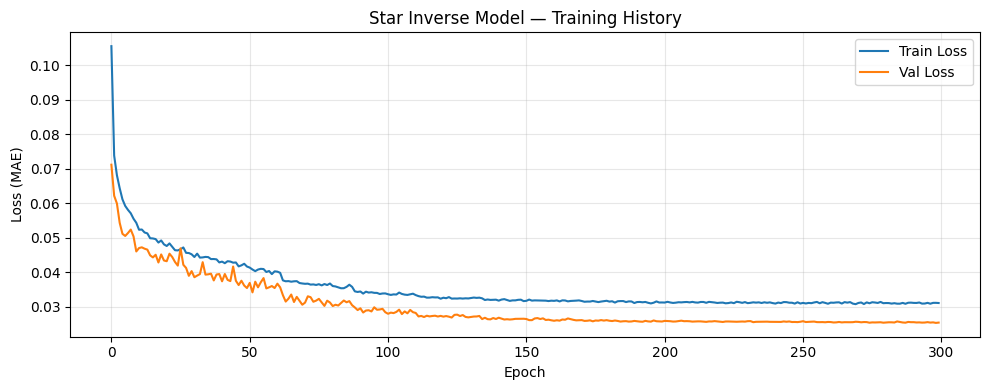

Final Train Loss: 0.03104
Final Val Loss:   0.02536
Ratio (val/train): 0.82x

--- Star Inverse Model Evaluation ---
Dimension                 MAE     MAPE
--------------------------------------
Length                 0.6854    1.96%
Diameter               0.1780    2.20%
N_Points               0.3561    6.07%
Point_Length           0.0741    3.13%
Point_Base_Width       0.2695   20.16%
Throat_Dia             0.0076    0.49%
Exit_Dia               0.0101    0.43%


In [8]:
# ── Training curve ────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history_inv.history['loss'],     label='Train Loss')
plt.plot(history_inv.history['val_loss'], label='Val Loss')
plt.title('Star Inverse Model — Training History')
plt.xlabel('Epoch'); plt.ylabel('Loss (MAE)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

train_loss = history_inv.history['loss'][-1]
val_loss   = history_inv.history['val_loss'][-1]
print(f'Final Train Loss: {train_loss:.5f}')
print(f'Final Val Loss:   {val_loss:.5f}')
print(f'Ratio (val/train): {val_loss/train_loss:.2f}x')

# ── Per-dimension accuracy ────────────────────────────────────────────
y_pred_s = inverse_model.predict([yt_te_s, yp_te_s, ys_te_s], verbose=0)
y_pred   = s_X.inverse_transform(y_pred_s)
y_actual = X_test

DIM_NAMES = ['Length', 'Diameter', 'N_Points', 'Point_Length', 'Point_Base_Width', 'Throat_Dia', 'Exit_Dia']

print('\n--- Star Inverse Model Evaluation ---')
print(f'{"Dimension":<20} {"MAE":>8} {"MAPE":>8}')
print('-' * 38)
for i, col in enumerate(DIM_NAMES):
    mae  = np.mean(np.abs(y_pred[:, i] - y_actual[:, i]))
    mape = np.mean(np.abs((y_pred[:, i] - y_actual[:, i]) / (y_actual[:, i] + 1e-8))) * 100
    print(f'{col:<20} {mae:>8.4f} {mape:>7.2f}%')


MC Dropout — Sample #0
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   38.683    0.000     40.000     3.3%  🟢 High
Diameter                  8.258    0.001      8.000     3.2%  🟢 High
N_Points                  7.292    0.006      7.000     4.2%  🟢 High
Point_Length              2.039    0.002      2.000     2.0%  🟢 High
Point_Base_Width          1.539    0.009      1.500     2.6%  🟢 High
Throat_Dia                1.994    0.003      2.000     0.3%  🟢 High
Exit_Dia                  2.992    0.002      3.000     0.3%  🟢 High


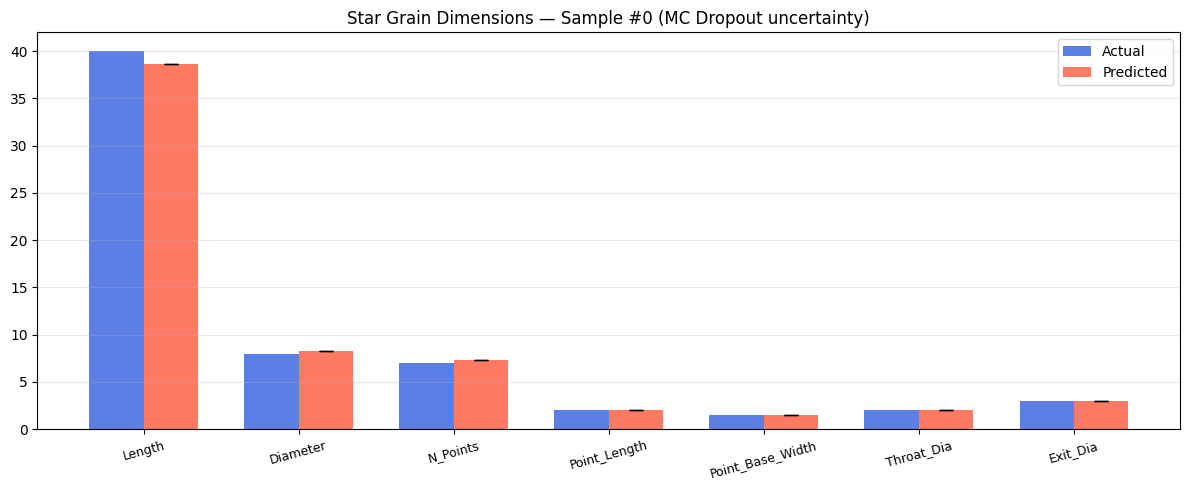


MC Dropout — Sample #50
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   20.003    0.000     20.000     0.0%  🟢 High
Diameter                 10.276    0.001     10.000     2.8%  🟢 High
N_Points                  4.683    0.010      5.000     6.3%  🟢 High
Point_Length              3.899    0.003      3.500    11.4%  🟢 High
Point_Base_Width          1.934    0.013      1.500    28.9%  🟢 High
Throat_Dia                1.989    0.005      2.000     0.6%  🟢 High
Exit_Dia                  2.983    0.004      3.000     0.6%  🟢 High


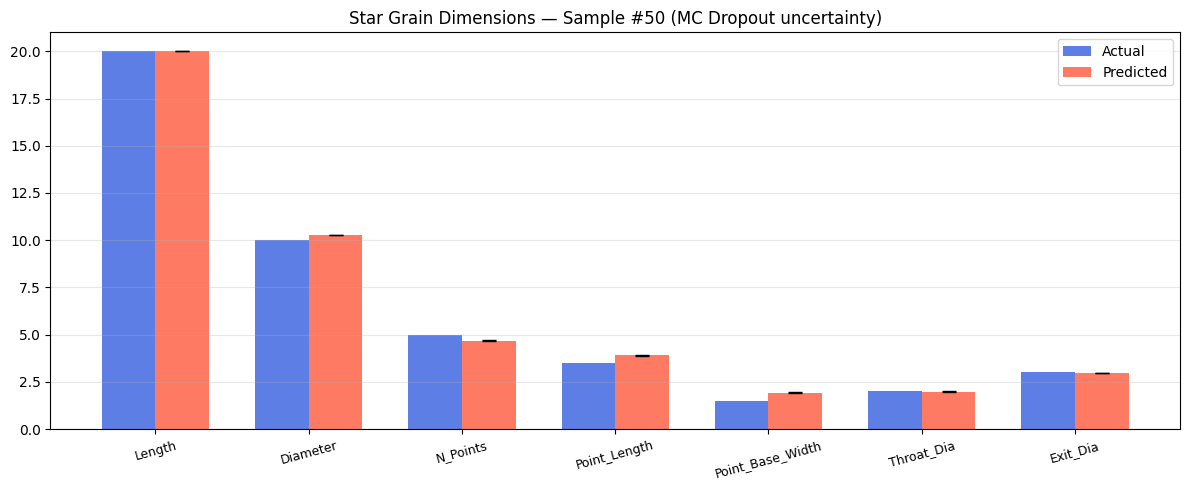


MC Dropout — Sample #100
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   20.010    0.000     20.000     0.0%  🟢 High
Diameter                  6.015    0.001      6.000     0.2%  🟢 High
N_Points                  3.039    0.001      3.000     1.3%  🟢 High
Point_Length              1.484    0.001      1.500     1.1%  🟢 High
Point_Base_Width          1.188    0.011      0.500   137.6%  🟢 High
Throat_Dia                0.935    0.019      0.900     3.9%  🟢 High
Exit_Dia                  1.390    0.012      1.350     3.0%  🟢 High


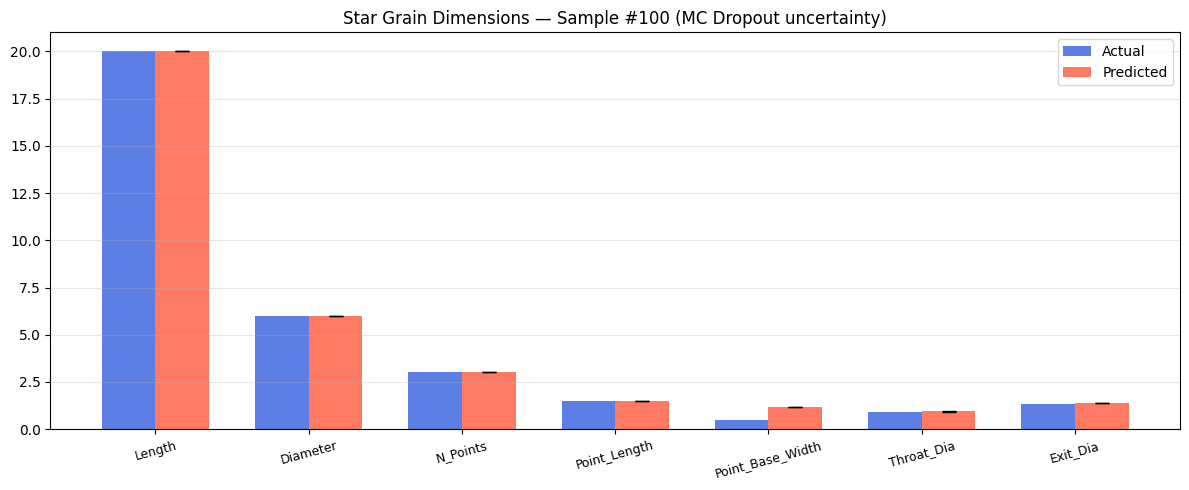

In [9]:
def mc_predict(t_in, p_in, s_in, n_iter=200):
    """Monte Carlo Dropout: يشغل الـ Dropout وقت الـ inference عشان نقدر نحسب uncertainty."""
    t_tensor = tf.constant(t_in, dtype=tf.float32)
    p_tensor = tf.constant(p_in, dtype=tf.float32)
    s_tensor = tf.constant(s_in, dtype=tf.float32)

    preds = []
    for _ in range(n_iter):
        out = inverse_model([t_tensor, p_tensor, s_tensor], training=True)
        preds.append(out.numpy())

    preds_arr = np.stack(preds, axis=0)
    return preds_arr.mean(axis=0), preds_arr.std(axis=0)


def show_uncertainty(sample_idx=0):
    t_s = yt_te_s[sample_idx:sample_idx+1]
    p_s = yp_te_s[sample_idx:sample_idx+1]
    s_s = ys_te_s[sample_idx:sample_idx+1]
    actual = X_test[sample_idx]

    pred_mean_s, pred_std_s = mc_predict(t_s, p_s, s_s, n_iter=200)

    pred_vals = s_X.inverse_transform(pred_mean_s)[0]
    pred_unc  = pred_std_s[0] * s_X.scale_

    print(f'\nMC Dropout — Sample #{sample_idx}')
    print('=' * 75)
    print(f'{"Dimension":<20} {"Predicted":>10} {"±σ":>8} {"Actual":>10} {"Err%":>8} Confidence')
    print('=' * 75)

    for i, name in enumerate(DIM_NAMES):
        err  = abs(pred_vals[i] - actual[i]) / (actual[i] + 1e-9) * 100
        cv   = pred_unc[i] / (abs(pred_vals[i]) + 1e-9) * 100
        conf = '🟢 High' if cv < 5 else ('🟡 Medium' if cv < 15 else '🔴 Low')
        print(f'{name:<20} {pred_vals[i]:>10.3f} {pred_unc[i]:>8.3f} {actual[i]:>10.3f} {err:>7.1f}%  {conf}')

    print('=' * 75)

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(7)
    width = 0.35
    ax.bar(x - width/2, actual,    width, label='Actual',    color='royalblue', alpha=0.85)
    ax.bar(x + width/2, pred_vals, width, label='Predicted', color='tomato',    alpha=0.85,
           yerr=pred_unc, capsize=5, error_kw={'linewidth': 2})
    ax.set_xticks(x)
    ax.set_xticklabels(DIM_NAMES, rotation=15, fontsize=9)
    ax.set_title(f'Star Grain Dimensions — Sample #{sample_idx} (MC Dropout uncertainty)')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()


show_uncertainty(0)
show_uncertainty(50)
show_uncertainty(100)


Reading: /kaggle/input/datasets/mahmoudabdelrazekk/tttttttttttttt/12.0.xlsx
  ⚠️  ISP column not found — using estimated 170s (typical for star grain)

  Predicted Star Grain Dimensions (cm)
  Length              : 20.2127 cm
  Outer Diameter      : 4.3114 cm
  Number of Points    : 3.0237 cm
  Point Length        : 1.5102 cm
  Point Base Width    : 1.2895 cm
  Throat Diameter     : 1.0197 cm
  Exit Diameter       : 1.5197 cm
  (Scalars used → ISP: 170.0s | Impulse: 486.7Ns | Burn: 2.26s | MaxThrust: 431.1N)


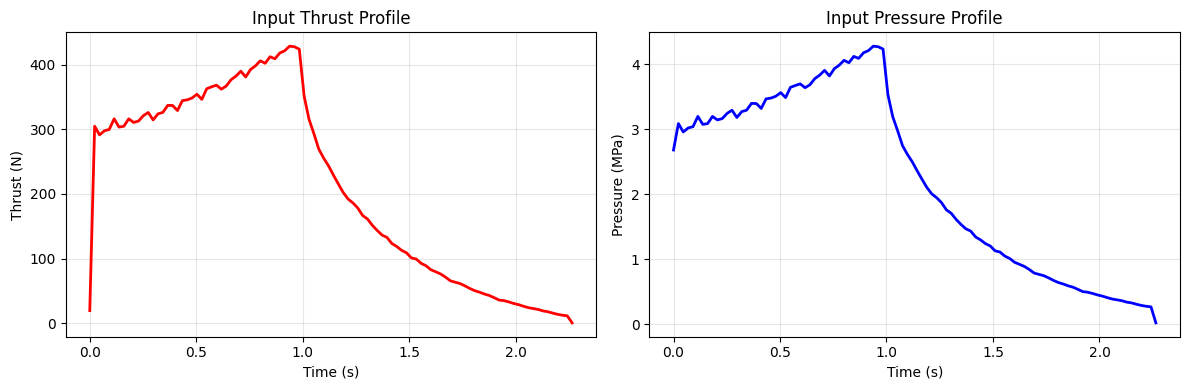

In [11]:
def predict_star_dims_from_file(file_path):
    """
    Input file (CSV or Excel) must have columns: Time, Thrust, Pressure
    Optional: ISP column
    
    Returns the 7 predicted Star Grain dimensions (cm).
    """
    print(f'\nReading: {file_path}')

    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    # ── Read file ────────────────────────────────────────────────────
    if file_path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip', skip_blank_lines=True)

    # ── Auto-detect columns ──────────────────────────────────────────
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if   'time' in c or c == 't':              col_map['time']     = col
        elif 'thrust' in c or c == 'f':            col_map['thrust']   = col
        elif 'pressure' in c or c == 'p':          col_map['pressure'] = col
        elif 'isp' in c:                           col_map['isp']      = col

    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        print(f'Columns found: {list(df.columns)}')
        raise ValueError('Cannot find Time, Thrust, or Pressure columns.')

    # ── Extract & smooth ─────────────────────────────────────────────
    df = df.sort_values(col_map['time']).dropna(subset=[col_map['time'], col_map['thrust'], col_map['pressure']])
    t        = df[col_map['time']].values
    thrust   = df[col_map['thrust']].values
    pressure = df[col_map['pressure']].values

    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # ── Interpolate to 100 points ────────────────────────────────────
    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # ── Compute scalars ───────────────────────────────────────────────
    burn_time     = t[-1]
    max_thrust    = np.max(thrust)
    total_impulse = trapezoid(thrust, t)
    isp = df[col_map['isp']].iloc[0] if 'isp' in col_map else 170.0
    if 'isp' not in col_map:
        print('  ⚠️  ISP column not found — using estimated 170s (typical for star grain)')
    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    # ── Scale inputs ──────────────────────────────────────────────────
    t_scaled = s_yt.transform(thrust_100.reshape(1, -1))
    p_scaled = s_yp.transform(pressure_100.reshape(1, -1))
    s_scaled = s_ys.transform(scalars.reshape(1, -1))

    # ── Predict ───────────────────────────────────────────────────────
    pred_s    = inverse_model.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    pred_dims = s_X.inverse_transform(pred_s)[0]
    pred_dims = np.maximum(pred_dims, 0.1)  # safety: no negative dimensions

    # ── Print results ─────────────────────────────────────────────────
    print('\n' + '='*55)
    print('  Predicted Star Grain Dimensions (cm)')
    print('='*55)
    labels = [
        'Length              ',
        'Outer Diameter      ',
        'Number of Points    ',
        'Point Length        ',
        'Point Base Width    ',
        'Throat Diameter     ',
        'Exit Diameter       ',
    ]
    for lbl, val in zip(labels, pred_dims):
        print(f'  {lbl}: {val:.4f} cm')
    print('='*55)
    print(f'  (Scalars used → ISP: {isp:.1f}s | Impulse: {total_impulse:.1f}Ns | Burn: {burn_time:.2f}s | MaxThrust: {max_thrust:.1f}N)')

    # ── Plot input profiles ───────────────────────────────────────────
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(x_new, thrust_100, color='red', linewidth=2)
    plt.title('Input Thrust Profile'); plt.xlabel('Time (s)'); plt.ylabel('Thrust (N)')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(x_new, pressure_100, color='blue', linewidth=2)
    plt.title('Input Pressure Profile'); plt.xlabel('Time (s)'); plt.ylabel('Pressure (MPa)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    return dict(zip(DIM_NAMES, pred_dims))


# ── تغيير المسار حسب ملفك ──────────────────────────────────────────
predicted = predict_star_dims_from_file('/kaggle/input/datasets/mahmoudabdelrazekk/tttttttttttttt/12.0.xlsx')
# predicted = predict_star_dims_from_file('profile.xlsx')

In [12]:
inverse_model.save('Star_inverse_model.keras')
print('Star_inverse_model.keras saved ✓')
# Scalers already saved in Cell 2
print('All 4 scalers already saved ✓')
print()
print('Files saved:')
print('  Star_inverse_model.keras')
print('  star_inv_scaler_dimensions.pkl')
print('  star_inv_scaler_thrust.pkl')
print('  star_inv_scaler_pressure.pkl')
print('  star_inv_scaler_scalars.pkl')

Star_inverse_model.keras saved ✓
All 4 scalers already saved ✓

Files saved:
  Star_inverse_model.keras
  star_inv_scaler_dimensions.pkl
  star_inv_scaler_thrust.pkl
  star_inv_scaler_pressure.pkl
  star_inv_scaler_scalars.pkl
